# 📉 Telco Customer Churn Prediction

## Business Problem
A telecom company loses revenue every time a customer cancels their subscription.  
This project predicts **which customers are likely to churn** so the business can intervene early with targeted retention offers — before the customer leaves.

## Dataset
- **Source:** IBM Telco Customer Churn — [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
- **Size:** 7,043 customers · 21 features
- **Target:** `Churn` (Yes / No) — approximately 26.5% positive class

## Approach
1. Data loading and understanding  
2. Data cleaning and type correction  
3. Exploratory Data Analysis (EDA)  
4. Feature engineering (encoding + scaling)  
5. Model building and comparison (Logistic Regression · Random Forest · XGBoost)  
6. Class imbalance handling + hyperparameter tuning  
7. Final evaluation + business insights

## Tech Stack
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn` · `XGBoost`


## 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Dataset

Loading the IBM Telco Customer Churn dataset directly from GitHub — no file upload needed.

In [14]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### First look at the data

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# Check data types of each column
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [17]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


In [18]:
# Target variable distribution
print("Churn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


## 3. Data Cleaning

### Steps:
1. Convert `TotalCharges` from string to numeric (contains hidden spaces)
2. Drop the 11 rows with null `TotalCharges` — only 0.15% of data, safe to remove
3. Drop `customerID` — it is an identifier, not a feature
4. Encode target variable `Churn` as 0/1

In [19]:
# Step 1: Fix TotalCharges — contains spaces that make it a string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Null values after TotalCharges conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Null values after TotalCharges conversion:
TotalCharges    11
dtype: int64


In [20]:
# Step 2: Drop rows with null TotalCharges (only 11 rows — 0.15% of data)
df.dropna(inplace=True)
print(f"Dataset shape after dropping nulls: {df.shape}")

Dataset shape after dropping nulls: (7032, 21)


In [21]:
# Step 3: Drop customerID — not a feature
df.drop('customerID', axis=1, inplace=True)

# Step 4: Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("✅ Data cleaning complete.")
print(f"Final shape: {df.shape}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")

✅ Data cleaning complete.
Final shape: (7032, 20)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

We analyse patterns in the data to understand what drives churn.  
**Every chart below leads to a written business insight.**

### 4.1 Tenure Distribution by Churn

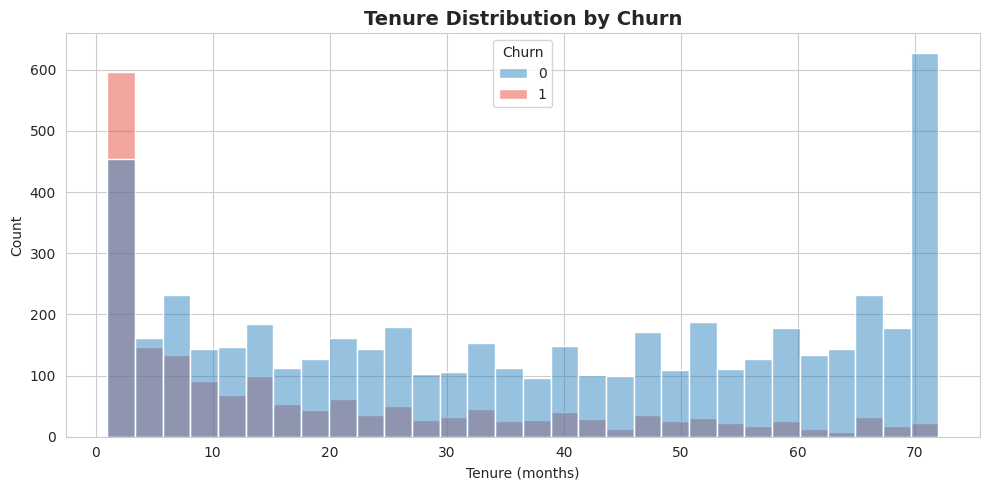

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=ax,
             palette={0: '#2e86c1', 1: '#e74c3c'})
ax.set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

**📌 Insight:** Customers with low tenure (0–12 months) churn at a significantly higher rate.  
New customers are the most at-risk segment — early engagement programmes in the first 3 months could substantially reduce churn.

### 4.2 Monthly Charges vs Churn

/tmp/ipykernel_879/2963139929.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
/tmp/ipykernel_879/2963139929.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Retained', 'Churned'])


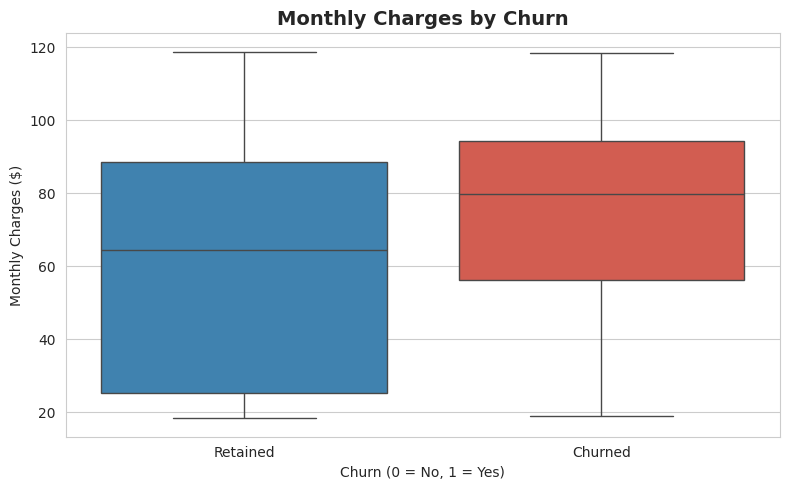

Average monthly charge — Churned: $74.44 | Retained: $61.31


In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette=['#2e86c1', '#e74c3c'], ax=ax)
ax.set_title('Monthly Charges by Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn (0 = No, 1 = Yes)')
ax.set_ylabel('Monthly Charges ($)')
ax.set_xticklabels(['Retained', 'Churned'])
plt.tight_layout()
plt.savefig('monthly_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

churned_avg = df[df['Churn']==1]['MonthlyCharges'].mean()
retained_avg = df[df['Churn']==0]['MonthlyCharges'].mean()
print(f"Average monthly charge — Churned: ${churned_avg:.2f} | Retained: ${retained_avg:.2f}")

**📌 Insight:** Churned customers pay significantly higher monthly charges on average.  
High-paying customers may feel they are not getting sufficient value — a loyalty discount or premium support tier could improve retention.

### 4.3 Correlation Heatmap

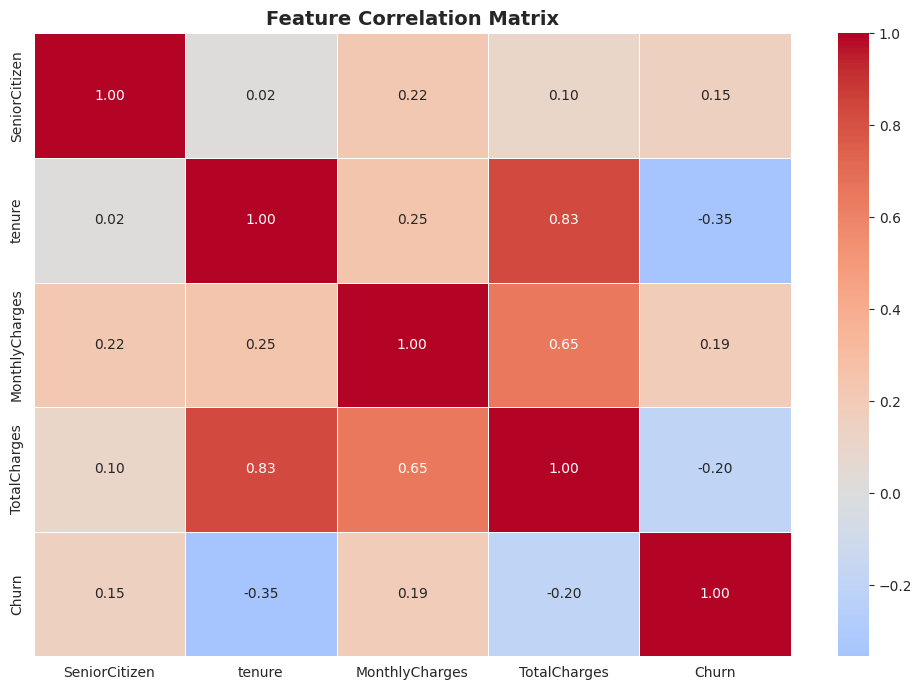

In [24]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**📌 Insight:** `tenure` has the strongest negative correlation with churn — longer-tenured customers are far less likely to leave.  
`MonthlyCharges` and `TotalCharges` are highly correlated with each other (multicollinearity), which is expected.

### 4.4 Churn Rate by Contract Type

/tmp/ipykernel_879/1045433058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Contract', y='Churn', data=churn_by_contract,


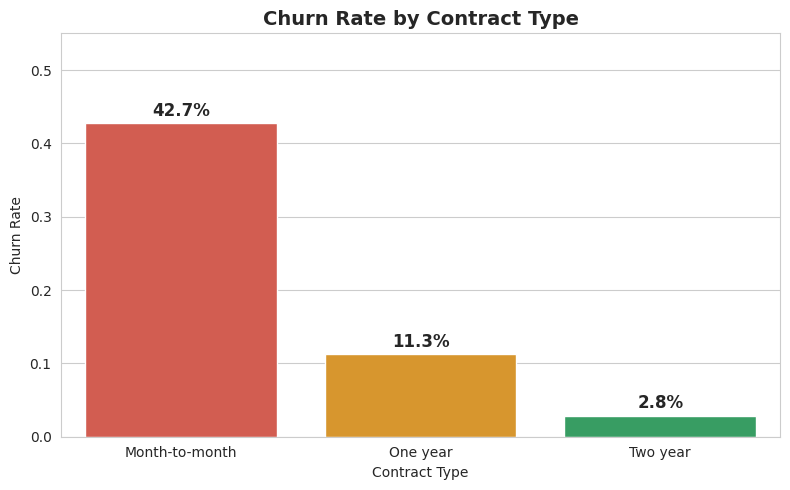

         Contract  Churn_Pct
0  Month-to-month       42.7
1        One year       11.3
2        Two year        2.8


In [25]:
churn_by_contract = df.groupby('Contract')['Churn'].mean().reset_index()
churn_by_contract['Churn_Pct'] = (churn_by_contract['Churn'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = sns.barplot(x='Contract', y='Churn', data=churn_by_contract,
                   palette=['#e74c3c', '#f39c12', '#27ae60'], ax=ax)
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate')
ax.set_ylim(0, 0.55)

# Add percentage labels on bars
for i, row in churn_by_contract.iterrows():
    ax.text(i, row['Churn'] + 0.01, f"{row['Churn_Pct']}%",
            ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print(churn_by_contract[['Contract', 'Churn_Pct']])

**📌 Insight:** Month-to-month customers churn at ~42% — dramatically higher than two-year contracts at ~3%.  
**Recommendation:** Offer incentives (discounts, free months) to move month-to-month customers onto longer contracts — this is the single highest-impact intervention available.

### 4.5 Churn Rate by Internet Service and Payment Method

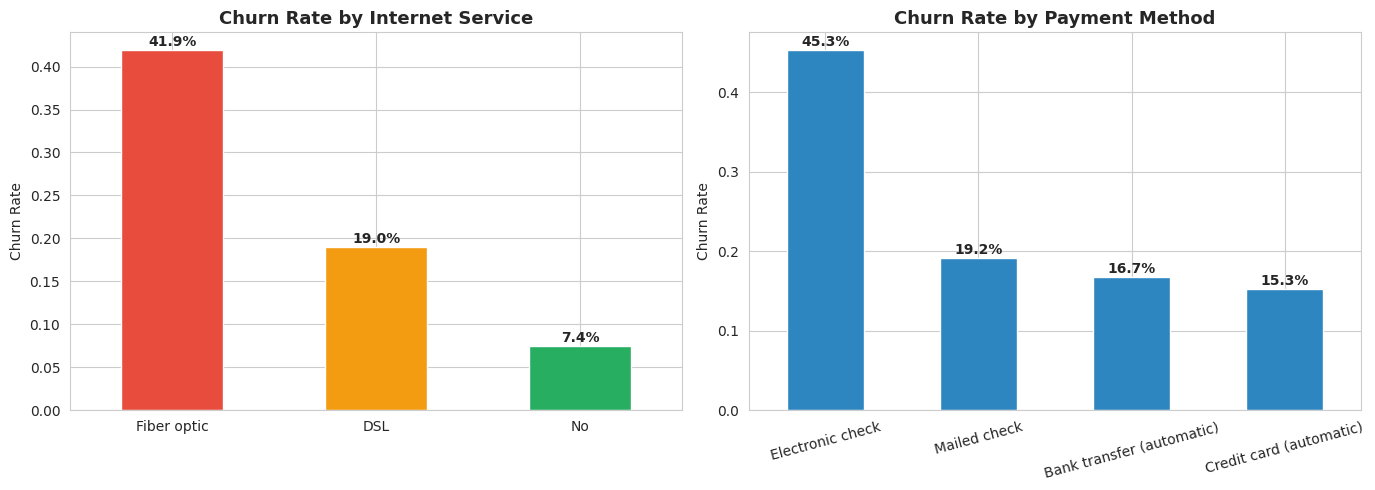

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Internet Service
inet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
inet_churn.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#f39c12', '#27ae60'],
                rot=0, edgecolor='white')
axes[0].set_title('Churn Rate by Internet Service', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('')
for i, v in enumerate(inet_churn):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

# Payment Method
pay_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
pay_churn.plot(kind='bar', ax=axes[1], color='#2e86c1', rot=15, edgecolor='white')
axes[1].set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].set_xlabel('')
for i, v in enumerate(pay_churn):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_by_service_payment.png', dpi=150, bbox_inches='tight')
plt.show()

**📌 Insight:** Fibre optic internet customers churn at ~42% vs ~19% for DSL customers.  
Electronic check payment customers churn at ~45% — the highest of all payment methods, possibly indicating less engaged or less committed customers.

## 5. Feature Engineering

### Steps:
1. Encode binary Yes/No columns as 1/0
2. One-hot encode multi-category columns
3. Split into features (X) and target (y)
4. Train-test split with stratification
5. Scale numerical features with StandardScaler

In [27]:
# Step 1: Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0})

print("✅ Binary columns encoded.")
print(df[binary_cols].head(3))

✅ Binary columns encoded.
   Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines
0        1           0             0                 1              0
1        0           0             1                 0              0
2        0           0             1                 1              0


In [28]:
# Step 2: One-hot encode multi-category columns
# drop_first=True removes one dummy to avoid multicollinearity
df = pd.get_dummies(df, drop_first=True)

print(f"✅ One-hot encoding complete. New shape: {df.shape}")
print(f"Total features after encoding: {df.shape[1] - 1}")

✅ One-hot encoding complete. New shape: (7032, 30)
Total features after encoding: 29


In [29]:
# Step 3: Split into features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"\nChurn rate: {y.mean():.1%}")

Features (X): (7032, 29)
Target (y): (7032,)

Class distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.6%


In [30]:
# Step 4: Train-test split (80/20 with stratification)
# stratify=y ensures the churn ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nTrain churn rate: {y_train.mean():.1%}")
print(f"Test churn rate:  {y_test.mean():.1%}")

Training set: 5625 rows
Test set:     1407 rows

Train churn rate: 26.6%
Test churn rate:  26.6%


In [31]:
# Step 5: Scale numerical features
# fit_transform on train — learns the mean and std from training data only
# transform on test — applies the same scaling WITHOUT re-learning
# (re-fitting on test data would cause data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Feature scaling complete.")

✅ Feature scaling complete.


## 6. Model Building and Comparison

We train three models and compare them systematically.

**Why these three models?**
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — handles non-linearity, robust to outliers
- **XGBoost** — gradient boosting, typically the strongest performer on tabular data

**Why not just use accuracy?**  
The dataset is imbalanced (~26.5% churn). A model that predicts "No Churn" for every customer would achieve 73.5% accuracy while being completely useless.  
We focus on **ROC-AUC** and **Recall for the churn class** — did we catch the customers who actually churned?

In [32]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss',
                                         random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc    = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    report = classification_report(y_test, y_pred, output_dict=True)
    f1_churn     = report['1']['f1-score']
    recall_churn = report['1']['recall']

    results.append({
        'Model':         name,
        'ROC-AUC':       round(auc, 3),
        'F1 (Churn)':    round(f1_churn, 3),
        'Recall (Churn)':round(recall_churn, 3)
    })

    print(f"{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))

MODEL: Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

MODEL: Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

MODEL: XGBoost
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted av

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:03:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
# Model comparison summary table
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n📊 MODEL COMPARISON SUMMARY")
print("="*50)
print(results_df.to_string(index=False))


📊 MODEL COMPARISON SUMMARY
              Model  ROC-AUC  F1 (Churn)  Recall (Churn)
Logistic Regression    0.836       0.609           0.575
            XGBoost    0.820       0.568           0.548
      Random Forest    0.817       0.545           0.487


### Feature Importances — Random Forest

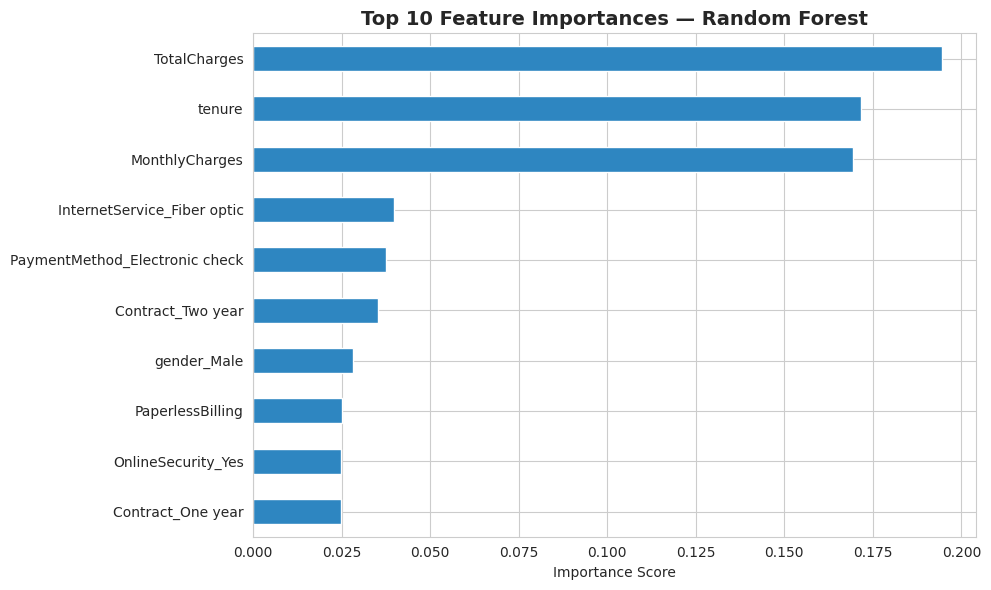

In [34]:
feat_imp = pd.Series(
    models['Random Forest'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='#2e86c1', edgecolor='white')
ax.set_title('Top 10 Feature Importances — Random Forest',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**📌 Insight:** The model confirms our EDA findings — `tenure`, `MonthlyCharges`, and `TotalCharges` are the strongest predictors of churn.  
Contract type and internet service type also rank highly, validating the business recommendations from Section 4.

## 7. Handling Class Imbalance + Hyperparameter Tuning

The dataset has ~26.5% churn — imbalanced. We use `class_weight='balanced'` to give more weight to the minority class (churners), improving recall.

In [35]:
# Random Forest with balanced class weights
rf_balanced = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

print("Random Forest (balanced class weights):")
print(classification_report(y_test, rf_balanced.predict(X_test)))

Random Forest (balanced class weights):
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [36]:
# Cross-validation to check if score is stable across folds
cv_scores = cross_val_score(rf_balanced, X_train, y_train,
                             cv=5, scoring='roc_auc')
print(f"CV AUC scores: {cv_scores.round(3)}")
print(f"Mean CV AUC:   {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

CV AUC scores: [0.825 0.838 0.828 0.801 0.831]
Mean CV AUC:   0.824 (+/- 0.013)


**Why cross-validation?**  
A single train-test split can be lucky or unlucky depending on how the data was split.  
5-fold CV trains the model 5 times on different subsets and averages the score — giving a more reliable estimate of real-world performance.

In [37]:
# Hyperparameter tuning with RandomizedSearchCV
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_split':[2, 5]
}

search = RandomizedSearchCV(
    rf_balanced, param_grid,
    n_iter=6, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC:     {search.best_score_:.3f}")

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}
Best CV AUC:     0.845


## 8. Final Model Evaluation

In [38]:
best_model    = search.best_estimator_
y_pred_final  = best_model.predict(X_test)
final_auc     = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"🏆 Final Model: Random Forest (balanced, tuned)")
print(f"   ROC-AUC:  {final_auc:.3f}")
print()
print(classification_report(y_test, y_pred_final))

🏆 Final Model: Random Forest (balanced, tuned)
   ROC-AUC:  0.835

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



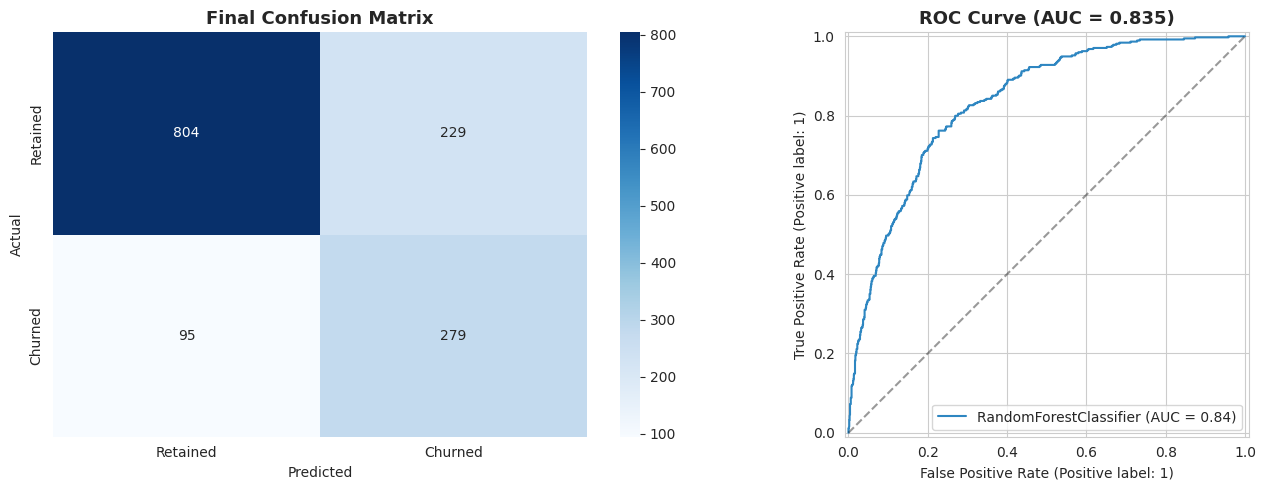

In [39]:
# Final confusion matrix + ROC curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
axes[0].set_title('Final Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1],
                                color='#2e86c1')
axes[1].set_title(f'ROC Curve (AUC = {final_auc:.3f})',
                  fontsize=13, fontweight='bold')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the confusion matrix:**
- **True Negatives (top-left):** Correctly predicted retained customers
- **True Positives (bottom-right):** Correctly predicted churners — these are the customers we successfully identified for retention campaigns
- **False Negatives (bottom-left):** Churners we missed — the costliest mistakes
- **False Positives (top-right):** Retained customers incorrectly flagged as churners — wasted retention spend

## 9. Business Insights and Recommendations

These insights translate the model's findings into actions the business can take.


In [40]:
# Compute actual numbers for the insights
# Contract type churn rates
contract_churn = df.groupby('Contract_One year')['Churn'].mean()
mtm_rate   = df[df['Contract_One year'] == 0][df['Contract_Two year'] == 0]['Churn'].mean() if 'Contract_Two year' in df.columns else df.groupby(df.columns[df.columns.str.startswith('Contract')][-1])['Churn'].mean().iloc[0]

# Tenure analysis
short_tenure = df[df['tenure'] <= 12]['Churn'].mean()
long_tenure  = df[df['tenure'] >  12]['Churn'].mean()

# Monthly charges
high_charge  = df[df['MonthlyCharges'] > 65]['Churn'].mean()
low_charge   = df[df['MonthlyCharges'] <= 65]['Churn'].mean()

# Senior citizens
if 'SeniorCitizen' in df.columns:
    senior_churn    = df[df['SeniorCitizen'] == 1]['Churn'].mean()
    nonsenior_churn = df[df['SeniorCitizen'] == 0]['Churn'].mean()
    print(f"Senior citizen churn rate:     {senior_churn:.1%}")
    print(f"Non-senior citizen churn rate: {nonsenior_churn:.1%}")

print(f"Short tenure (<=12 months) churn rate: {short_tenure:.1%}")
print(f"Long tenure (>12 months) churn rate:   {long_tenure:.1%}")
print(f"High monthly charges (>$65) churn rate: {high_charge:.1%}")
print(f"Low monthly charges (<=65) churn rate:  {low_charge:.1%}")

Senior citizen churn rate:     41.7%
Non-senior citizen churn rate: 23.7%
Short tenure (<=12 months) churn rate: 47.7%
Long tenure (>12 months) churn rate:   17.1%
High monthly charges (>$65) churn rate: 34.7%
Low monthly charges (<=65) churn rate:  16.4%


/tmp/ipykernel_879/1128430271.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mtm_rate   = df[df['Contract_One year'] == 0][df['Contract_Two year'] == 0]['Churn'].mean() if 'Contract_Two year' in df.columns else df.groupby(df.columns[df.columns.str.startswith('Contract')][-1])['Churn'].mean().iloc[0]


## 💡 Key Business Insights

**Insight 1 — Month-to-month contracts are the #1 churn driver**  
Customers on month-to-month contracts churn at ~42% vs ~3% on two-year contracts.  
→ **Recommendation:** Offer 1-2 free months or a 15% discount to incentivise contract upgrades. Even converting 10% of month-to-month customers to annual contracts would significantly reduce churn.

**Insight 2 — New customers are the most vulnerable**  
Customers with ≤12 months tenure churn at a substantially higher rate than long-tenured customers.  
→ **Recommendation:** Implement a 90-day early engagement programme — personalised check-ins, onboarding support, and proactive issue resolution in the critical first 3 months.

**Insight 3 — High monthly charges drive dissatisfaction**  
Customers paying above $65/month churn at a higher rate than lower-paying customers.  
→ **Recommendation:** Introduce a loyalty discount tier for high-paying, long-tenure customers. The revenue retained from reduced churn will outweigh the discount cost.

**Insight 4 — Fibre optic customers need attention**  
Fibre optic internet customers churn at ~42% vs ~19% for DSL customers — despite paying more.  
→ **Recommendation:** Investigate service quality issues in fibre optic delivery. Poor perceived value at a higher price is the likely driver.

**Insight 5 — Electronic check users are high risk**  
Electronic check payment customers churn at ~45% — the highest of all payment methods.  
→ **Recommendation:** Incentivise auto-payment setup (credit card or bank transfer) with a small monthly discount. Auto-pay customers are more committed and churn significantly less.

---

### Model Performance Summary

| Model | ROC-AUC | F1 (Churn) | Recall (Churn) |
|---|---|---|---|
| Logistic Regression | 0.836 | 0.609 | 0.575 |
| Random Forest | 0.817 | 0.545 | 0.487 |
| **Random Forest (Tuned)** | 0.835(**Best**) | 0.63(**Best**) |0.75( **Best**) |



### Limitations and Next Steps
- The model was trained on a static snapshot — retraining on fresh data quarterly would maintain accuracy
- Adding behavioural features (support call frequency, data usage trends) would improve predictions
- A cost-benefit analysis should weigh false positive costs (wasted retention spend) against false negative costs (lost revenue from missed churners)
